# 01 Exploratory Data Analysis


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path('..')/'src'))


## Objectives

- Understand distributions of key variables (price, subscribers, profit, reviews).
- Compare subjects and levels.
- Identify modeling issues: skew, outliers, potential transformations.

**Input:** `data/processed/courses_clean.parquet`


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path('..') / 'data' / 'processed' / 'courses_clean.parquet'
df = pd.read_parquet(DATA_PATH)
df.shape


(3677, 19)

In [3]:
df[['price','num_subscribers','num_reviews','profit','num_lectures','content_duration_hours']].describe().T


,count,mean,std,min,25%,50%,75%,max
price,3677.0,66.045689,6.101574e+01,0.0,20.0,45.0,95.0,200.0
num_subscribers,3677.0,3186.810171,9.482219e+03,0.0,111.0,912.0,2543.0,268923.0
num_reviews,3677.0,156.560511,9.358035e+02,0.0,4.0,18.0,67.0,27445.0
profit,3677.0,239797.666576,1.000309e+06,0.0,1615.0,23100.0,118600.0,24316800.0
num_lectures,3677.0,40.093555,5.040051e+01,0.0,15.0,25.0,46.0,779.0
content_duration_hours,3347.0,4.436361,6.242125e+00,1.0,1.5,2.5,5.0,78.5


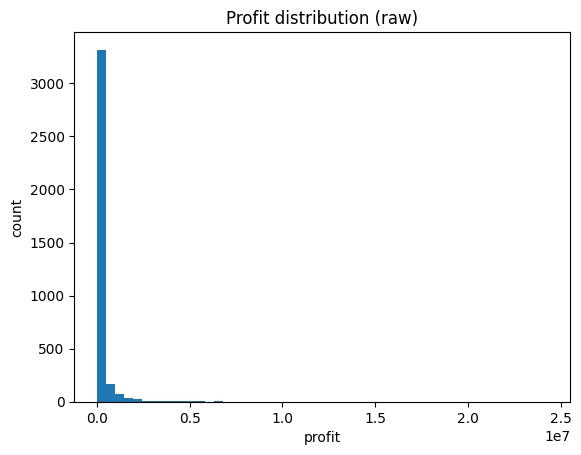

In [4]:
# Profit is usually heavy-tailed
plt.figure()
plt.hist(df['profit'], bins=50)
plt.title('Profit distribution (raw)')
plt.xlabel('profit')
plt.ylabel('count')
plt.show()


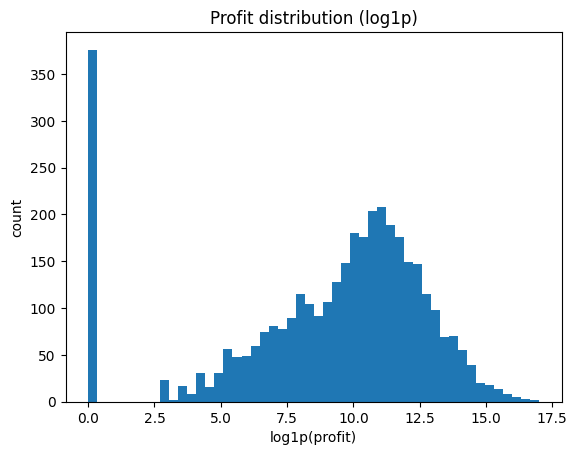

In [5]:
import numpy as np

plt.figure()
plt.hist(np.log1p(df['profit']), bins=50)
plt.title('Profit distribution (log1p)')
plt.xlabel('log1p(profit)')
plt.ylabel('count')
plt.show()


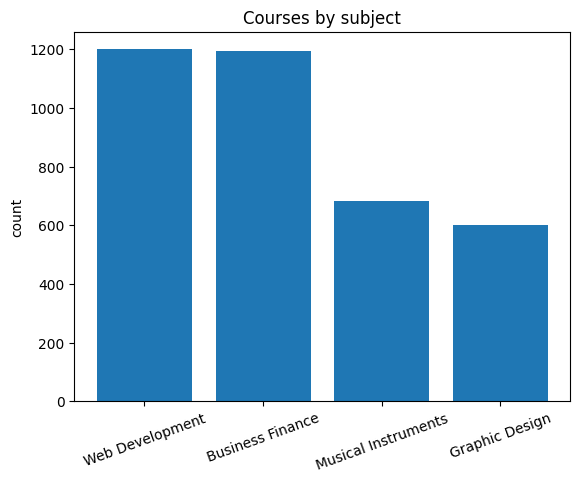

In [6]:
# Subject-wise counts
subj_counts = df['subject'].value_counts()
plt.figure()
plt.bar(subj_counts.index, subj_counts.values)
plt.title('Courses by subject')
plt.xticks(rotation=20)
plt.ylabel('count')
plt.show()


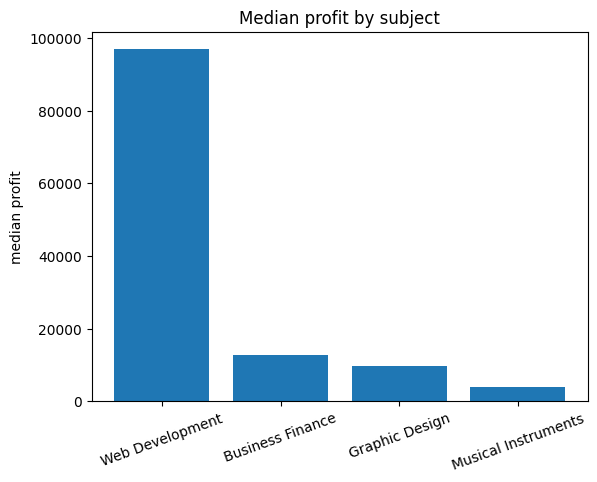

In [7]:
# Median profit by subject
med_profit = df.groupby('subject')['profit'].median().sort_values(ascending=False)
plt.figure()
plt.bar(med_profit.index, med_profit.values)
plt.title('Median profit by subject')
plt.xticks(rotation=20)
plt.ylabel('median profit')
plt.show()


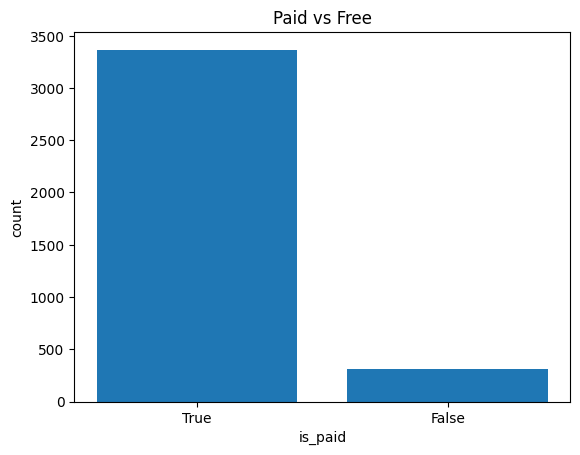

In [8]:
# Paid vs free
paid = df['is_paid'].value_counts()
plt.figure()
plt.bar(paid.index.astype(str), paid.values)
plt.title('Paid vs Free')
plt.xlabel('is_paid')
plt.ylabel('count')
plt.show()


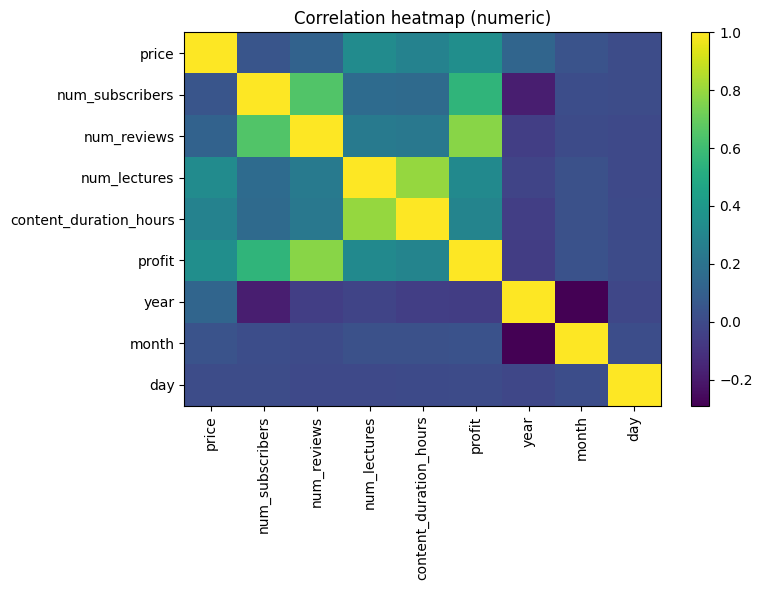

In [9]:
# Simple correlation (numeric features only)
num_cols = ['price','num_subscribers','num_reviews','num_lectures','content_duration_hours','profit','year','month','day']
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.title('Correlation heatmap (numeric)')
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.tight_layout()
plt.show()
